# Outfit Recommender — Combined Embeddings + LLM Selection

Recommends complete outfits using a two-stage pipeline:
1. **Combined embeddings** (FashionCLIP image + metadata text, averaged) for retrieval
2. **LLM** for complementarity reasoning over a small candidate set

**Flow:**
- Detect anchor category from query (keyword match → embedding fallback)
- Retrieve top-`CANDIDATES_PER_CATEGORY` from anchor category via embedding similarity
- Retrieve top-`CANDIDATES_PER_CATEGORY` from each remaining category
- LLM picks the best combo from the shortlisted candidates

**Setup:** `.env` with `OPENROUTER_API_KEY` (or `OPENAI_API_KEY`). `pip install -r requirements.txt`

Run **Sections 1–7** once per session, then edit **Section 8 (Config)** and run **Steps A–F**.

## 1. Imports and project paths

In [1]:
from __future__ import annotations

import json
import math
import os
import re
import uuid
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import torch
from dotenv import load_dotenv
from openai import OpenAI
from PIL import Image
from transformers import CLIPModel, CLIPProcessor

load_dotenv()


def project_root() -> Path:
    here = Path.cwd().resolve()
    if here.name == 'notebooks' and (here / 'images').is_dir():
        return here
    if (here / 'notebooks').is_dir():
        return here / 'notebooks'
    return here


ROOT = project_root()
(ROOT / 'outputs').mkdir(parents=True, exist_ok=True)
print(f'ROOT: {ROOT}')

ROOT: /Users/mohitjoshi/Projects/fashion-app/notebooks


## 2. Metadata helpers

Load all JSON metadata files and convert each item into a text description suitable for embedding with FashionCLIP's text encoder.

In [2]:
def load_all_metadata(metadata_dir: Path) -> dict[str, dict]:
    """Returns {filename: metadata_dict} for all JSON files in metadata_dir."""
    result: dict[str, dict] = {}
    for p in sorted(metadata_dir.glob('*.json')):
        try:
            meta = json.loads(p.read_text())
            filename = meta.get('filename') or (p.stem + '.jpeg')
            result[filename] = meta
        except Exception as e:
            print(f'  Warning: skipping {p.name} — {e}')
    return result


def metadata_to_text(meta: dict) -> str:
    """Flatten metadata to a single descriptive string for text embedding."""
    colors = ', '.join(meta.get('colors', {}).get('all', []))
    pattern = meta.get('visual_attributes', {}).get('pattern', '')
    material = meta.get('visual_attributes', {}).get('material', '')
    fit = meta.get('shape_fit', {}).get('fit', '')
    silhouette = meta.get('shape_fit', {}).get('silhouette', '')
    style_tags = ', '.join(meta.get('style', {}).get('style_tags', []))
    occasions = ', '.join(meta.get('style', {}).get('occasion_suitability', []))
    seasons = ', '.join(meta.get('seasonality', {}).get('season', []))
    formality = meta.get('style', {}).get('formality', '')

    parts = [
        f"type: {meta.get('type', '')}",
        f"category: {meta.get('category', '')}",
        f"colors: {colors}",
        f"pattern: {pattern}",
        f"material: {material}",
        f"fit: {fit} {silhouette}".strip(),
        f"style: {style_tags}",
        f"occasion: {occasions}",
        f"season: {seasons}",
        f"formality: {formality}",
    ]
    return '; '.join(p for p in parts if p.split(': ', 1)[-1])


def group_by_category(wardrobe: dict[str, dict]) -> dict[str, list[str]]:
    """Returns {category: [filename, ...]}."""
    groups: dict[str, list[str]] = {}
    for filename, meta in wardrobe.items():
        cat = meta.get('category', 'unknown')
        groups.setdefault(cat, []).append(filename)
    return groups

## 3. FashionCLIP model and embedding helpers

In [3]:
def load_fashionclip(
    model_name: str = 'patrickjohncyh/fashion-clip',
    local_dir: Path | None = None,
) -> tuple[CLIPModel, CLIPProcessor, torch.device]:
    device = torch.device(
        'mps' if torch.backends.mps.is_available()
        else 'cuda' if torch.cuda.is_available()
        else 'cpu'
    )
    local_dir = local_dir or (ROOT / 'models' / 'fashion-clip')
    if local_dir.exists():
        print(f'Loading from local cache: {local_dir}')
        source = str(local_dir)
    else:
        print(f'Downloading {model_name!r} from HuggingFace ...')
        source = model_name
    processor = CLIPProcessor.from_pretrained(source)
    model = CLIPModel.from_pretrained(source).to(device).eval()
    if source == model_name:
        local_dir.mkdir(parents=True, exist_ok=True)
        model.save_pretrained(str(local_dir))
        processor.save_pretrained(str(local_dir))
        print(f'Saved to {local_dir}')
    print(f'Model ready on {device}.')
    return model, processor, device


def _image_feats(model: CLIPModel, pixel_values: torch.Tensor) -> torch.Tensor:
    pooled = model.vision_model(pixel_values=pixel_values).pooler_output
    return model.visual_projection(pooled)


def _text_feats(model: CLIPModel, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    pooled = model.text_model(input_ids=input_ids, attention_mask=attention_mask).pooler_output
    return model.text_projection(pooled)


def embed_images_batch(
    paths: list[Path],
    *,
    model: CLIPModel,
    processor: CLIPProcessor,
    device: torch.device,
    batch_size: int = 16,
) -> np.ndarray:
    """L2-normalised image embeddings, shape (N, D)."""
    all_vecs: list[np.ndarray] = []
    for start in range(0, len(paths), batch_size):
        batch = paths[start: start + batch_size]
        images = [Image.open(p).convert('RGB') for p in batch]
        pv = processor(images=images, return_tensors='pt')['pixel_values'].to(device)
        with torch.no_grad():
            feats = _image_feats(model, pv)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        all_vecs.append(feats.cpu().float().numpy())
    return np.concatenate(all_vecs, axis=0)


def embed_texts_batch(
    texts: list[str],
    *,
    model: CLIPModel,
    processor: CLIPProcessor,
    device: torch.device,
    batch_size: int = 32,
) -> np.ndarray:
    """L2-normalised text embeddings, shape (N, D)."""
    all_vecs: list[np.ndarray] = []
    for start in range(0, len(texts), batch_size):
        batch = texts[start: start + batch_size]
        enc = processor(text=batch, return_tensors='pt', padding=True, truncation=True)
        input_ids = enc['input_ids'].to(device)
        attention_mask = enc['attention_mask'].to(device)
        with torch.no_grad():
            feats = _text_feats(model, input_ids, attention_mask)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        all_vecs.append(feats.cpu().float().numpy())
    return np.concatenate(all_vecs, axis=0)


def embed_query(query: str, *, model: CLIPModel, processor: CLIPProcessor, device: torch.device) -> np.ndarray:
    """L2-normalised query embedding, shape (1, D)."""
    return embed_texts_batch([query], model=model, processor=processor, device=device)

## 4. Combined embedding cache

Each item's combined embedding = average of its L2-normalised image embedding and L2-normalised metadata-text embedding, then re-normalised. This gives FashionCLIP visual grounding plus semantic attributes (occasion, season, formality) in the same 512-dim CLIP space.

In [4]:
def build_combined_embeddings(
    wardrobe: dict[str, dict],
    images_dir: Path,
    cache_path: Path,
    *,
    model: CLIPModel,
    processor: CLIPProcessor,
    device: torch.device,
    alpha: float = 0.5,
    force: bool = False,
) -> tuple[np.ndarray, list[str]]:
    """
    Returns (embeddings, filenames) where embeddings[i] is the combined
    embedding for filenames[i]. Uses disk cache unless force=True.
    alpha controls image weight (1-alpha = metadata text weight).
    """
    if not force and cache_path.is_file():
        data = np.load(cache_path, allow_pickle=False)
        print(f'Loaded combined embedding cache: {len(data["filenames"])} items')
        return data['embeddings'], data['filenames'].tolist()

    filenames = [fn for fn in wardrobe if (images_dir / fn).is_file()]
    if not filenames:
        raise FileNotFoundError(f'No matching images found in {images_dir}')

    print(f'Building combined embeddings for {len(filenames)} items ...')

    # Image embeddings
    paths = [images_dir / fn for fn in filenames]
    image_vecs = embed_images_batch(paths, model=model, processor=processor, device=device)

    # Metadata text embeddings (same CLIP text encoder)
    texts = [metadata_to_text(wardrobe[fn]) for fn in filenames]
    text_vecs = embed_texts_batch(texts, model=model, processor=processor, device=device)

    # Weighted average, then re-normalise
    combined = alpha * image_vecs + (1.0 - alpha) * text_vecs
    norms = np.linalg.norm(combined, axis=-1, keepdims=True)
    combined = combined / np.where(norms > 0, norms, 1.0)

    cache_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez(cache_path, embeddings=combined, filenames=np.array(filenames))
    print(f'Saved cache -> {cache_path}  (dim={combined.shape[1]})')
    return combined, filenames

## 5. Anchor detection and per-category retrieval

In [5]:
# Keywords that map a query token to a wardrobe category
_CATEGORY_KEYWORDS: dict[str, list[str]] = {
    'top':       ['top', 'blouse', 'shirt', 't-shirt', 'tshirt', 'tee', 'sweater', 'knit', 'tank'],
    'bottom':    ['bottom', 'pants', 'skirt', 'jeans', 'trousers', 'shorts', 'leggings'],
    'outerwear': ['outerwear', 'jacket', 'blazer', 'coat', 'vest', 'cardigan', 'hoodie'],
    'dress':     ['dress', 'gown', 'romper', 'jumpsuit'],
    'footwear':  ['shoes', 'boots', 'sneakers', 'heels', 'sandals', 'footwear'],
}


def detect_anchor_category(
    query: str,
    available_categories: list[str],
    embeddings: np.ndarray,
    filenames: list[str],
    wardrobe: dict[str, dict],
    *,
    model: CLIPModel,
    processor: CLIPProcessor,
    device: torch.device,
) -> str:
    """
    Step 1: keyword match — if the query mentions a category type, use it.
    Step 2: fallback — embed query, score all items, pick category with highest avg score.
    """
    query_lower = query.lower()
    tokens = re.split(r'[\s,;:./]+', query_lower)

    for cat, keywords in _CATEGORY_KEYWORDS.items():
        if cat in available_categories and any(kw in tokens for kw in keywords):
            print(f'Anchor detected by keyword: "{cat}"')
            return cat

    # Embedding fallback: highest average cosine similarity per category
    print('No keyword match — using embedding similarity to pick anchor category.')
    query_vec = embed_query(query, model=model, processor=processor, device=device)  # (1, D)
    scores = (embeddings @ query_vec.T).squeeze(-1)  # (N,)

    cat_scores: dict[str, float] = {}
    for i, fn in enumerate(filenames):
        cat = wardrobe[fn].get('category', 'unknown')
        if cat in available_categories:
            cat_scores.setdefault(cat, [])
            cat_scores[cat].append(scores[i])  # type: ignore[attr-defined]

    avg_scores = {cat: float(np.mean(v)) for cat, v in cat_scores.items()}  # type: ignore[arg-type]
    anchor = max(avg_scores, key=lambda c: avg_scores[c])
    print(f'Anchor by embedding avg score: "{anchor}" {avg_scores}')
    return anchor


def retrieve_top_k_for_category(
    category: str,
    query: str,
    embeddings: np.ndarray,
    filenames: list[str],
    wardrobe: dict[str, dict],
    *,
    model: CLIPModel,
    processor: CLIPProcessor,
    device: torch.device,
    top_k: int = 3,
) -> list[dict]:
    """
    Returns top-k items from `category`, ranked by cosine similarity to query.
    Each result: {filename, score, metadata}.
    """
    query_vec = embed_query(query, model=model, processor=processor, device=device)
    scores = (embeddings @ query_vec.T).squeeze(-1)

    cat_indices = [
        i for i, fn in enumerate(filenames)
        if wardrobe.get(fn, {}).get('category') == category
    ]
    if not cat_indices:
        return []

    cat_scores = [(i, float(scores[i])) for i in cat_indices]
    cat_scores.sort(key=lambda x: x[1], reverse=True)
    top = cat_scores[:top_k]

    return [
        {'filename': filenames[i], 'score': s, 'metadata': wardrobe[filenames[i]]}
        for i, s in top
    ]

## 6. LLM outfit selection

Sends shortlisted candidates (3 per category) to the LLM. The LLM reasons about complementarity — color contrast, formality alignment, occasion fit — and picks one item per category.

In [6]:
def _make_llm_client(provider: str) -> tuple[OpenAI, str]:
    """Returns (client, base_url) for the given provider."""
    if provider == 'openrouter':
        key = os.environ.get('OPENROUTER_API_KEY', '')
        if not key:
            raise EnvironmentError('OPENROUTER_API_KEY not set in .env')
        return OpenAI(api_key=key, base_url='https://openrouter.ai/api/v1'), 'openrouter'
    elif provider == 'openai':
        key = os.environ.get('OPENAI_API_KEY', '')
        if not key:
            raise EnvironmentError('OPENAI_API_KEY not set in .env')
        return OpenAI(api_key=key), 'openai'
    else:
        raise ValueError(f'Unsupported provider: {provider!r}. Use "openrouter" or "openai".')


def _format_candidates_for_prompt(candidates_by_cat: dict[str, list[dict]]) -> str:
    lines: list[str] = []
    for cat, items in candidates_by_cat.items():
        lines.append(f'\n### {cat.upper()} candidates')
        for item in items:
            meta = item['metadata']
            colors = ', '.join(meta.get('colors', {}).get('all', []))
            style_tags = ', '.join(meta.get('style', {}).get('style_tags', []))
            occasions = ', '.join(meta.get('style', {}).get('occasion_suitability', []))
            seasons = ', '.join(meta.get('seasonality', {}).get('season', []))
            pairing = ', '.join(meta.get('pairing_hints', {}).get('goes_well_with', []))
            avoid = ', '.join(meta.get('pairing_hints', {}).get('avoid_with', []))
            lines.append(
                f'- filename: {item["filename"]}\n'
                f'  type: {meta.get("type","?")} | colors: {colors} | '
                f'style: {style_tags} | occasion: {occasions} | season: {seasons}\n'
                f'  goes_well_with: {pairing} | avoid_with: {avoid}'
            )
    return '\n'.join(lines)


def select_outfit_with_llm(
    query: str,
    candidates_by_cat: dict[str, list[dict]],
    anchor_category: str,
    *,
    client: OpenAI,
    model: str,
    temperature: float = 0.3,
) -> dict:
    """
    LLM picks one item per category from the shortlisted candidates.
    Returns a dict with 'outfit' ({category: filename}), 'reasoning', and 'styling_tip'.
    """
    system = (
        'You are an expert fashion stylist. You will receive a user outfit request '
        'and a shortlist of wardrobe candidates per clothing category. '
        'Select the BEST single item per category that together form a cohesive, '
        'well-paired outfit. Consider: color harmony and contrast, formality alignment, '
        'occasion and season fit, and style compatibility. '
        'Return ONLY valid JSON — no markdown, no explanation outside the JSON.'
    )

    candidate_text = _format_candidates_for_prompt(candidates_by_cat)
    categories = list(candidates_by_cat.keys())

    user_msg = (
        f'User request: "{query}"\n'
        f'Anchor category (pick this first): {anchor_category}\n'
        f'{candidate_text}\n\n'
        f'Return JSON with exactly this structure:\n'
        '```\n'
        '{\n'
        '  "outfit": {\n'
        + ''.join(f'    "{cat}": "<chosen filename>",\n' for cat in categories)
        + '  },\n'
        '  "reasoning": "<2-3 sentences explaining why these items work together>",\n'
        '  "styling_tip": "<one actionable tip for wearing this outfit>"\n'
        '}\n'
        '```\n'
        'Only use filenames from the candidates above. '
        'If a category has no suitable match for the request, omit it from "outfit".'
    )

    response = client.chat.completions.create(
        model=model,
        messages=[
            {'role': 'system', 'content': system},
            {'role': 'user', 'content': user_msg},
        ],
        temperature=temperature,
    )

    raw = response.choices[0].message.content or '{}'
    # Strip markdown fences if present
    raw = re.sub(r'^```[\w]*\n?', '', raw.strip())
    raw = re.sub(r'\n?```$', '', raw.strip())
    return json.loads(raw)

## 7. Display helpers

In [7]:
def show_outfit(outfit: dict, reasoning: str, styling_tip: str, images_dir: Path, query: str) -> None:
    """Display selected outfit items in a grid with category labels."""
    items = list(outfit.items())  # [(category, filename), ...]
    n = len(items)
    if n == 0:
        print('No outfit selected.')
        return

    ncols = min(n, 4)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.8, nrows * 3.2))
    axes_list = np.array(axes).flatten() if n > 1 else [axes]

    for i, ax in enumerate(axes_list):
        ax.axis('off')
        if i < n:
            cat, filename = items[i]
            p = images_dir / filename
            if p.is_file():
                im = Image.open(p).convert('RGB')
                im.thumbnail((300, 300))
                ax.imshow(im)
            else:
                ax.text(0.5, 0.5, f'missing\n{filename}', ha='center', va='center', fontsize=9)
            ax.set_title(f'{cat}\n{filename}', fontsize=9, fontweight='bold')

    fig.suptitle(f'Query: "{query}"', fontsize=11, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print(f'\nReasoning: {reasoning}')
    print(f'Styling tip: {styling_tip}')


def show_candidates(candidates_by_cat: dict[str, list[dict]], images_dir: Path) -> None:
    """Debug view: show all shortlisted candidates per category with scores."""
    for cat, items in candidates_by_cat.items():
        print(f'\n--- {cat} candidates ---')
        fig, axes = plt.subplots(1, len(items), figsize=(len(items) * 2.5, 3))
        if len(items) == 1:
            axes = [axes]
        for ax, item in zip(axes, items):
            ax.axis('off')
            p = images_dir / item['filename']
            if p.is_file():
                im = Image.open(p).convert('RGB')
                im.thumbnail((200, 200))
                ax.imshow(im)
            ax.set_title(f"{item['filename']}\n{item['score']:.3f}", fontsize=8)
        plt.tight_layout()
        plt.show()

---

## 8. Config — edit here

Change `USER_QUERY` and re-run **Steps D–F** for a new recommendation without re-embedding.

Set `FORCE_REEMBED = True` after adding new images or metadata to rebuild the cache.

In [16]:
# --- Paths ---
IMAGES_DIR    = ROOT / 'images'
METADATA_DIR  = ROOT / 'metadata'
CACHE_PATH    = ROOT / 'outputs' / 'combined_embeddings.npz'

# --- Query ---
USER_QUERY = 'Season: Summer, Occasion: Party'

# --- Retrieval ---
CANDIDATES_PER_CATEGORY = 3   # top-k from each category before LLM selection
IMAGE_WEIGHT = 0.5            # alpha: 0.5 = equal image + metadata text weight
FORCE_REEMBED = False         # set True after adding images/metadata


### Step A — Load FashionCLIP model

In [17]:
clip_model, clip_processor, clip_device = load_fashionclip()

Loading from local cache: /Users/mohitjoshi/Projects/fashion-app/notebooks/models/fashion-clip


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Model ready on mps.


### Step B — Load metadata and group by category

In [18]:
wardrobe = load_all_metadata(METADATA_DIR)
category_groups = group_by_category(wardrobe)

print(f'Wardrobe: {len(wardrobe)} items')
for cat, fns in sorted(category_groups.items()):
    print(f'  {cat}: {len(fns)} items — {fns}')

Wardrobe: 23 items
  bottom: 13 items — ['17.jpeg', '19.jpeg', '2.jpeg', '20.jpeg', '3.jpeg', '4.jpeg', '5.jpeg', 's1.jpeg', 's2.jpeg', 's3.jpeg', 's4.jpeg', 's6.jpeg', 's7.jpeg']
  outerwear: 3 items — ['s11.jpeg', 's12.jpeg', 's13.jpeg']
  top: 7 items — ['8.jpeg', 's10.jpeg', 's14.jpeg', 's15.jpeg', 's5.jpeg', 's8.jpeg', 's9.jpeg']


### Step C — Build / load combined embeddings

In [19]:
embeddings, emb_filenames = build_combined_embeddings(
    wardrobe,
    IMAGES_DIR,
    CACHE_PATH,
    model=clip_model,
    processor=clip_processor,
    device=clip_device,
    alpha=IMAGE_WEIGHT,
    force=FORCE_REEMBED,
)
print(f'Embeddings: {embeddings.shape}')

Loaded combined embedding cache: 23 items
Embeddings: (23, 512)


### Step D — Detect anchor and retrieve candidates

No keyword match — using embedding similarity to pick anchor category.
Anchor by embedding avg score: "bottom" {'bottom': 0.40537744760513306, 'top': 0.3909384310245514, 'outerwear': 0.38348233699798584}
bottom: ['3.jpeg', '4.jpeg', '20.jpeg']
top: ['s14.jpeg', 's15.jpeg', 's8.jpeg']
outerwear: ['s12.jpeg', 's13.jpeg', 's11.jpeg']

--- bottom candidates ---


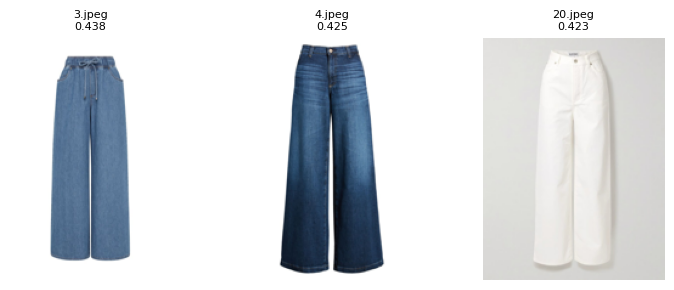


--- top candidates ---


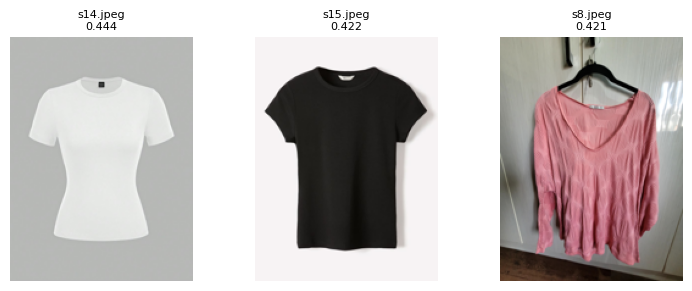


--- outerwear candidates ---


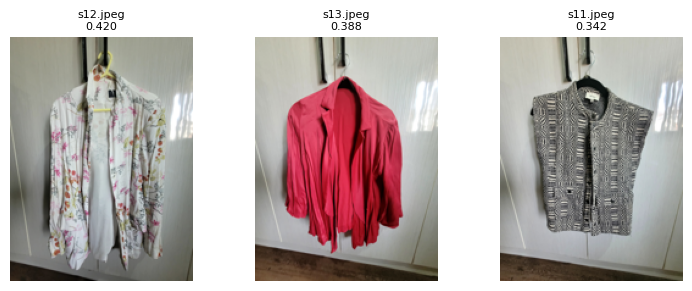

In [20]:
available_categories = list(category_groups.keys())

anchor_category = detect_anchor_category(
    USER_QUERY,
    available_categories,
    embeddings,
    emb_filenames,
    wardrobe,
    model=clip_model,
    processor=clip_processor,
    device=clip_device,
)

# Retrieve top-k for every category (anchor first, then the rest)
candidates_by_cat: dict[str, list[dict]] = {}
ordered_cats = [anchor_category] + [c for c in available_categories if c != anchor_category]

for cat in ordered_cats:
    top_items = retrieve_top_k_for_category(
        cat,
        USER_QUERY,
        embeddings,
        emb_filenames,
        wardrobe,
        model=clip_model,
        processor=clip_processor,
        device=clip_device,
        top_k=CANDIDATES_PER_CATEGORY,
    )
    if top_items:
        candidates_by_cat[cat] = top_items
        print(f'{cat}: {[i["filename"] for i in top_items]}')

# Optional: visualise the shortlist
show_candidates(candidates_by_cat, IMAGES_DIR)

### Step E — LLM outfit selection

In [21]:
# --- LLM ---
PROVIDER = 'openrouter'                          # 'openrouter' or 'openai'
LLM_MODEL = 'google/gemini-3.1-flash-image-preview'   # any model on your chosen provider

llm_client, _ = _make_llm_client(PROVIDER)

result = select_outfit_with_llm(
    USER_QUERY,
    candidates_by_cat,
    anchor_category,
    client=llm_client,
    model=LLM_MODEL,
)

print('LLM selection:')
print(json.dumps(result, indent=2))

LLM selection:
{
  "outfit": {
    "bottom": "20.jpeg",
    "top": "s8.jpeg",
    "outerwear": "s12.jpeg"
  },
  "reasoning": "The white pants provide a chic and summery base suitable for a party. The pink bohemian blouse adds a festive pop of color and texture, while the lightweight floral blazer ties the look together with a playful, dressy layer perfect for a summer event.",
  "styling_tip": "Pair this outfit with strappy sandals or wedges and some statement earrings to elevate the look for a party setting."
}


### Step F — Display final outfit

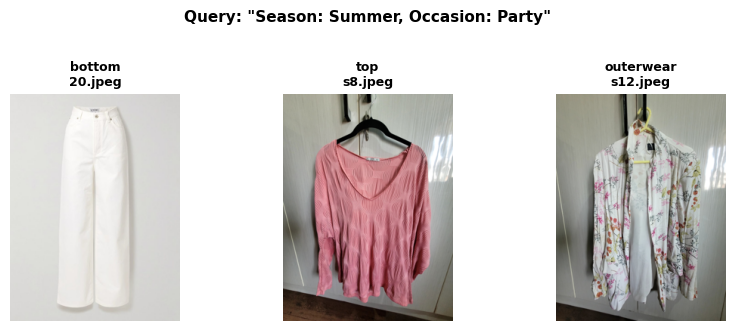


Reasoning: The white pants provide a chic and summery base suitable for a party. The pink bohemian blouse adds a festive pop of color and texture, while the lightweight floral blazer ties the look together with a playful, dressy layer perfect for a summer event.
Styling tip: Pair this outfit with strappy sandals or wedges and some statement earrings to elevate the look for a party setting.


In [22]:
show_outfit(
    outfit=result.get('outfit', {}),
    reasoning=result.get('reasoning', ''),
    styling_tip=result.get('styling_tip', ''),
    images_dir=IMAGES_DIR,
    query=USER_QUERY,
)